# ColBERT Evaluation Results

Reads pre-computed results from `eval_results/` and training logs from `output/`.

In [16]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join("..", "eval_results")
OUTPUT_DIR = os.path.join("..", "output")
RECALL_KS = [50, 200, 1000]

## Training Progress

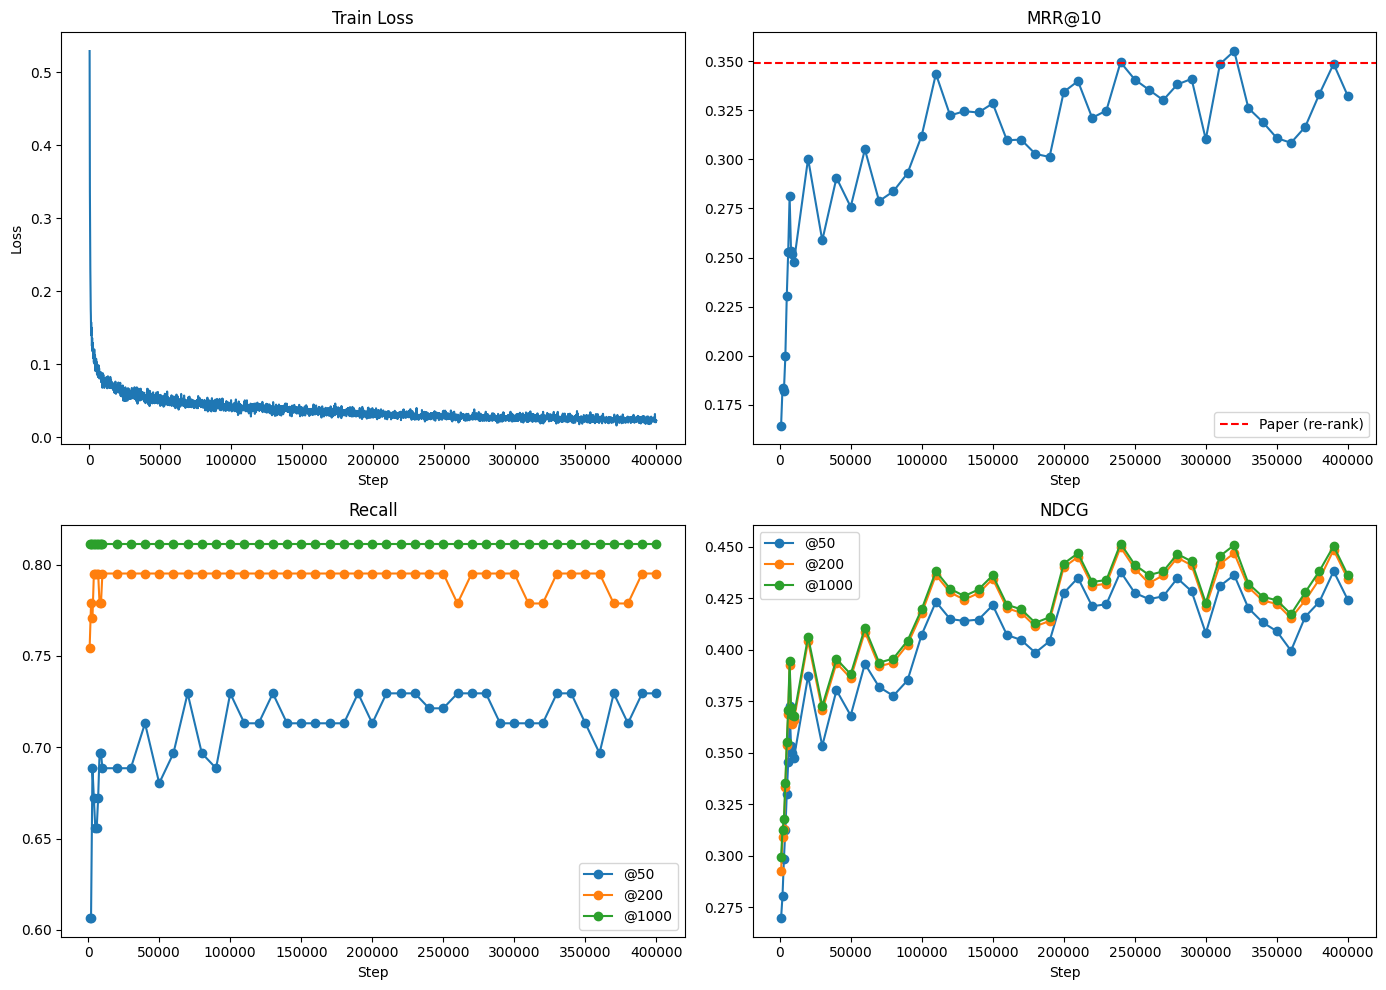

In [17]:
with open(os.path.join(OUTPUT_DIR, "training_log.json")) as f:
    log = json.load(f)

train_steps = [e["step"] for e in log["train_loss"]]
train_losses = [e["loss"] for e in log["train_loss"]]

val_entries = log.get("val_metrics", [])
val_steps = [e["step"] for e in val_entries]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_steps, train_losses)
axes[0, 0].set_title("Train Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")

if val_entries:
    mrr_vals = [e.get("MRR@10", 0) for e in val_entries]
    axes[0, 1].plot(val_steps, mrr_vals, marker="o")
    axes[0, 1].axhline(y=0.349, color="r", linestyle="--", label="Paper (re-rank)")
    axes[0, 1].set_title("MRR@10")
    axes[0, 1].set_xlabel("Step")
    axes[0, 1].legend()

    for k in [50, 200, 1000]:
        key = f"Recall@{k}"
        vals = [e.get(key, 0) for e in val_entries]
        if any(v > 0 for v in vals):
            axes[1, 0].plot(val_steps, vals, marker="o", label=f"@{k}")
    axes[1, 0].set_title("Recall")
    axes[1, 0].set_xlabel("Step")
    axes[1, 0].legend()

    for k in [50, 200, 1000]:
        key = f"NDCG@{k}"
        vals = [e.get(key, 0) for e in val_entries]
        if any(v > 0 for v in vals):
            axes[1, 1].plot(val_steps, vals, marker="o", label=f"@{k}")
    axes[1, 1].set_title("NDCG")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Evaluation Results

Load all results from `eval_results/` and compare against paper numbers.

In [18]:
result_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "eval_step_*.json")))
print(f"Found {len(result_files)} evaluation result(s)")

all_results = []
for path in result_files:
    with open(path) as f:
        all_results.append(json.load(f))

for r in all_results:
    print(f"\n--- Step {r['step']} ---")
    print(f"  ColBERT Rerank: MRR@10={r['colbert_rerank']['MRR@10']:.4f}")
    if "colbert_e2e" in r:
        print(f"  ColBERT E2E:    MRR@10={r['colbert_e2e']['MRR@10']:.4f}")

Found 1 evaluation result(s)

--- Step 200000 ---
  ColBERT Rerank: MRR@10=0.3506
  ColBERT E2E:    MRR@10=0.6477


In [19]:
paper_bm25 = {"MRR@10": 0.187, "Recall@50": 0.592, "Recall@200": 0.738, "Recall@1000": 0.814,
              "NDCG@50": None, "NDCG@200": None, "NDCG@1000": None}
paper_rerank = {"MRR@10": 0.349, "Recall@50": None, "Recall@200": None, "Recall@1000": None,
                "NDCG@50": None, "NDCG@200": None, "NDCG@1000": None}
paper_e2e = {"MRR@10": 0.360, "Recall@50": 0.829, "Recall@200": 0.923, "Recall@1000": 0.968,
             "NDCG@50": None, "NDCG@200": None, "NDCG@1000": None}

rows = []

if all_results:
    best = max(all_results, key=lambda r: r["colbert_rerank"]["MRR@10"])
    rows.append({"Method": f"ColBERT Re-rank (step {best['step']})", **best["colbert_rerank"]})
    if "colbert_e2e" in best:
        rows.append({"Method": f"ColBERT E2E (step {best['step']})", **best["colbert_e2e"]})

rows.append({"Method": "BM25 Anserini (paper)", **paper_bm25})
rows.append({"Method": "ColBERT Re-rank (paper)", **paper_rerank})
rows.append({"Method": "ColBERT E2E (paper)", **paper_e2e})

cols = ["MRR@10"] + [f"Recall@{k}" for k in RECALL_KS] + [f"NDCG@{k}" for k in RECALL_KS]
df = pd.DataFrame(rows).set_index("Method")[cols]
df.round(4)

,MRR@10,Recall@50,Recall@200,Recall@1000,NDCG@50,NDCG@200,NDCG@1000
Method,,,,,,,
ColBERT Re-rank (step 200000),0.3506,0.7535,0.8052,0.8140,0.4435,0.4517,0.4528
ColBERT E2E (step 200000),0.6477,0.9355,0.9543,0.9574,0.7142,0.7173,0.7177
BM25 Anserini (paper),0.1870,0.5920,0.7380,0.8140,NaN,NaN,NaN
ColBERT Re-rank (paper),0.3490,NaN,NaN,NaN,NaN,NaN,NaN
ColBERT E2E (paper),0.3600,0.8290,0.9230,0.9680,NaN,NaN,NaN


## MRR@10 Across Checkpoints

In [20]:
if len(all_results) > 1:
    steps = [r["step"] for r in all_results]
    mrr_bm25 = [r["bm25"]["MRR@10"] for r in all_results]
    mrr_colbert = [r["colbert_rerank"]["MRR@10"] for r in all_results]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, mrr_colbert, marker="o", label="ColBERT Re-rank")
    ax.axhline(y=mrr_bm25[0], color="gray", linestyle="--", label="BM25")
    ax.axhline(y=0.349, color="r", linestyle="--", label="Paper (re-rank)")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("MRR@10")
    ax.set_title("ColBERT MRR@10 vs Training Step")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Need multiple eval results to plot progression")

Need multiple eval results to plot progression
